# Assignment 2 – XAI: Chest X-Ray Pneumonia Detection
**Task:** Binary classification of chest X-ray images (Normal vs. Pneumonia)  
**Dataset:** [Kaggle – Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

---
### Notebook Structure
1. Setup & Kaggle API  
2. Dataset Exploration  
3. CNN Baseline  
4. Hyperparameter Optimization (Keras Tuner – Bayesian)  
5. Alternative Model (Transfer Learning – MobileNetV2)  
6. XAI: Grad-CAM  
7. XAI: Integrated Gradients  
8. Results Summary


## 1. Setup

In [ ]:
# Install extra packages (Colab already has TF/Keras)
!pip install keras-tuner -q
!pip install opencv-python
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os, cv2, warnings
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import confusion_matrix, classification_report
import keras_tuner as kt
import json
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras Tuner : {kt.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")


TensorFlow  : 2.19.0
Keras Tuner : 1.4.8
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1b. Download Dataset from Kaggle



In [ ]:
import os
os.environ['KAGGLE_TOKEN'] = 'KGAT_6805ba99e74e661bfe242dd258ff8f12'
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content
!unzip -q /content/chest-xray-pneumonia.zip -d /content/data
print("Dataset downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:57<00:00, 42.6MB/s]

Dataset downloaded and extracted.


In [ ]:
# Data paths
BASE_DIR  = '/content/data/chest_xray'   # adjust if needed
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (150, 150)
BATCH_SIZE = 32
SEED       = 42
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']


## 2. Dataset Exploration

In [ ]:
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        p = os.path.join(directory, cls)
        if os.path.isdir(p):
            counts[cls] = len(os.listdir(p))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

summary = pd.DataFrame({'Train': train_counts, 'Val': val_counts, 'Test': test_counts})
print(summary)
print(f"\nTotal images: {summary.values.sum()}")
print(f"Train imbalance ratio: {train_counts['PNEUMONIA']/train_counts['NORMAL']:.2f}x more PNEUMONIA")


           Train  Val  Test
NORMAL      1341    8   234
PNEUMONIA   3875    8   390

Total images: 5856
Train imbalance ratio: 2.89x more PNEUMONIA


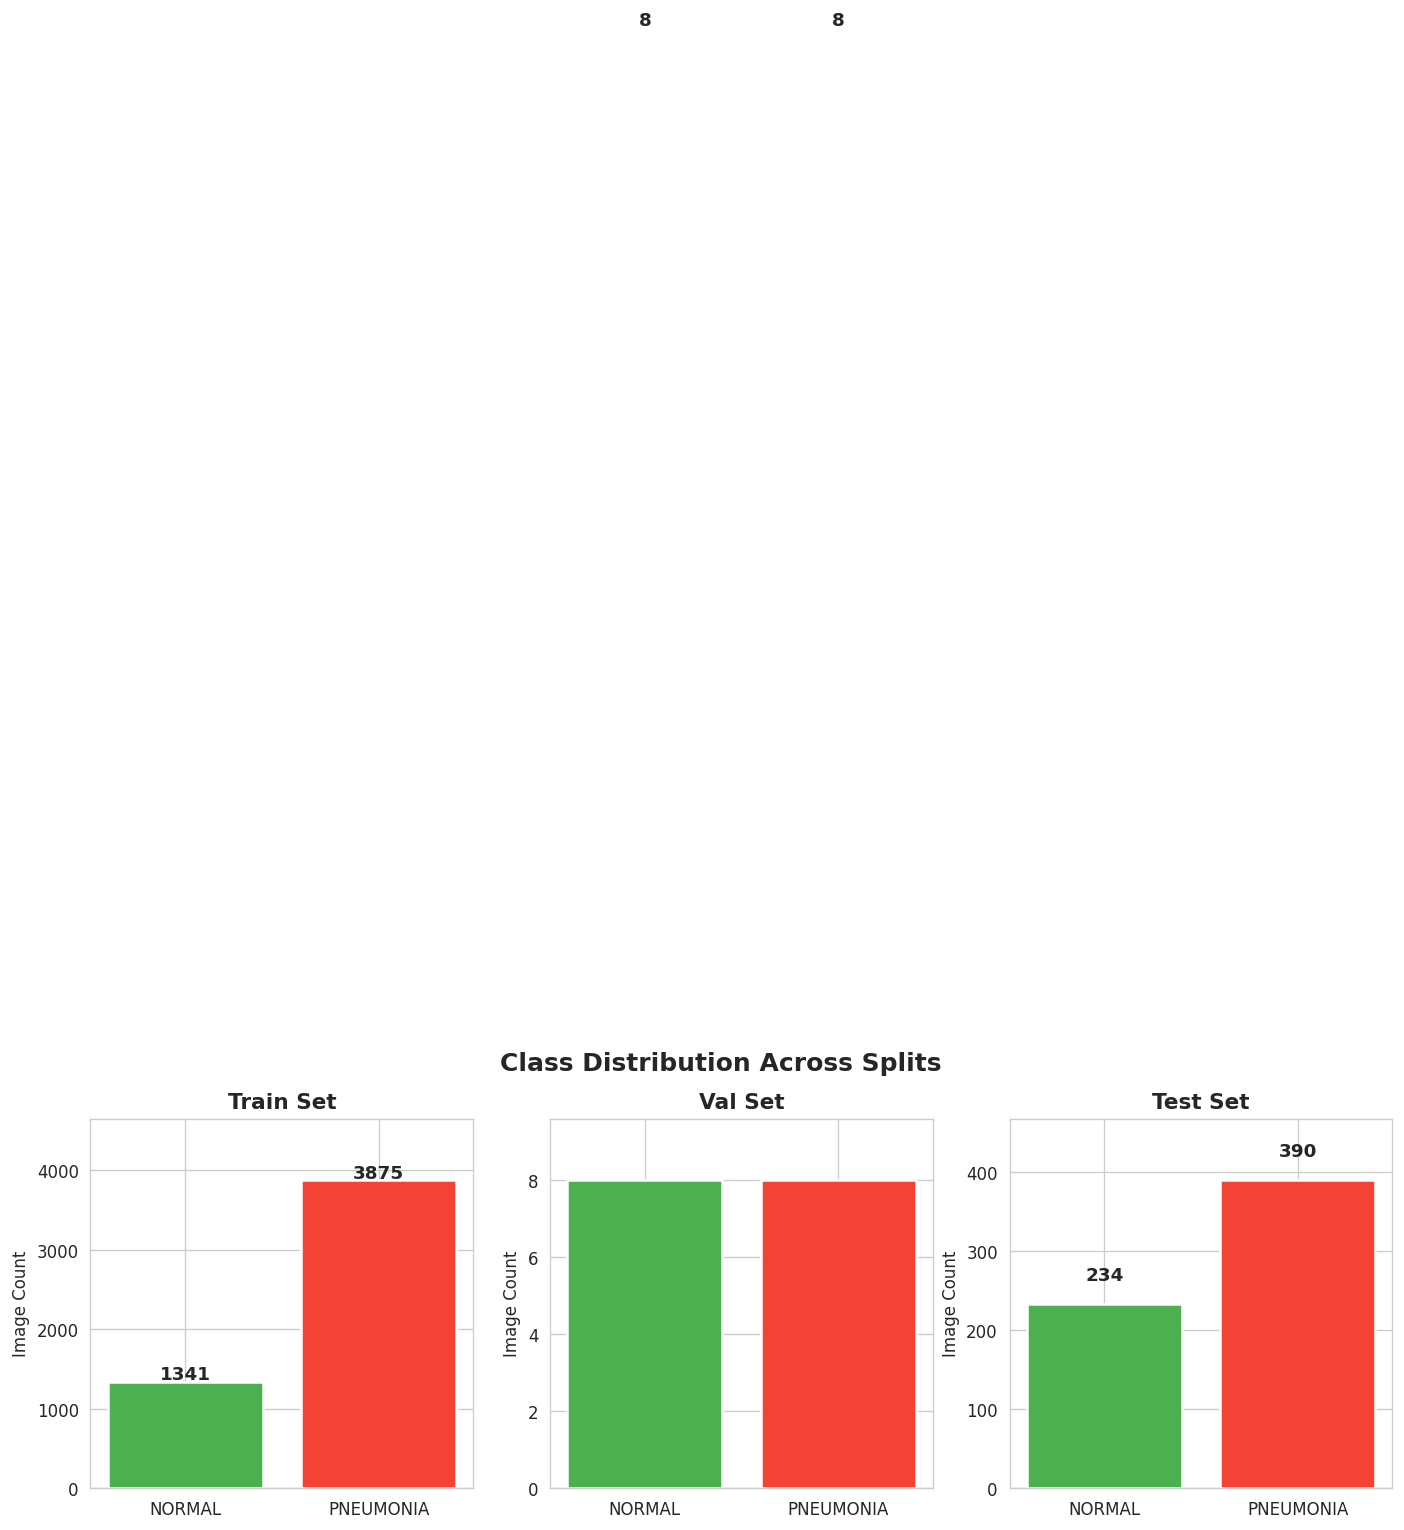

In [ ]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4CAF50', '#F44336']
for ax, (split, counts) in zip(axes, [('Train', train_counts),
                                       ('Val',   val_counts),
                                       ('Test',  test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{split} Set', fontsize=13, fontweight='bold')
    ax.set_ylabel('Image Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=11)
    ax.set_ylim(0, max(counts.values()) * 1.2)

plt.suptitle('Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()


NORMAL: shape=(1858, 2090, 3), pixel range=[0, 255]
PNEUMONIA: shape=(760, 1152, 3), pixel range=[0, 255]


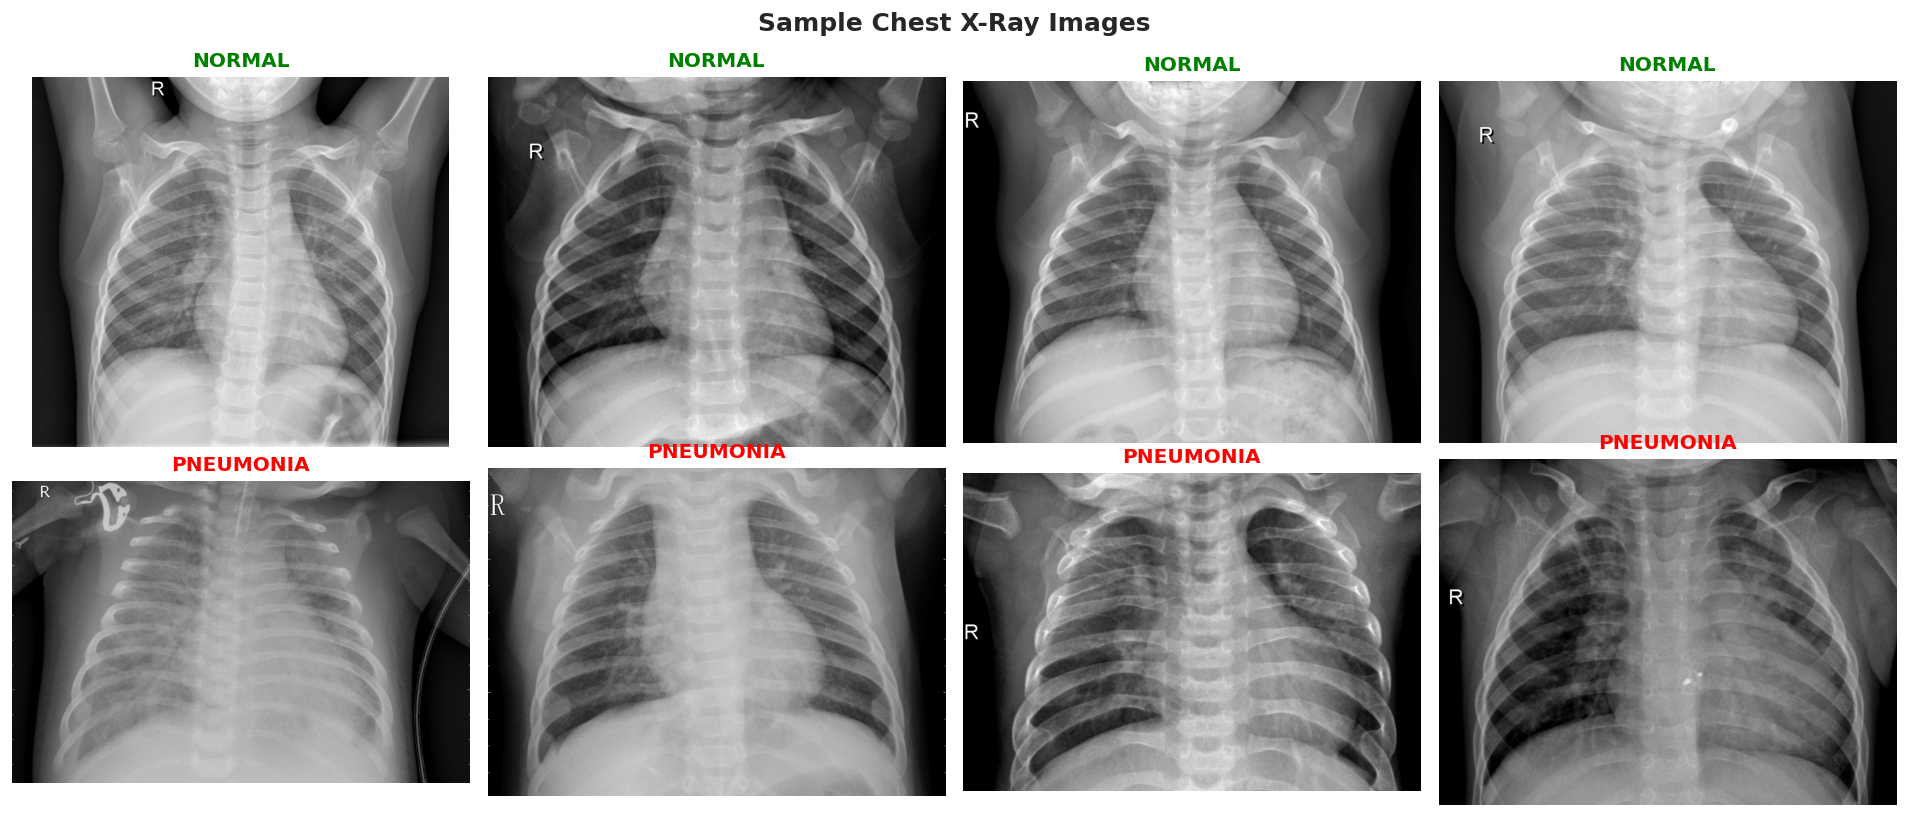

In [ ]:
# Sample images
def show_samples(directory, n_per_class=4):
    fig, axes = plt.subplots(2, n_per_class, figsize=(16, 7))
    for row, cls in enumerate(CLASS_NAMES):
        cls_path = os.path.join(directory, cls)
        imgs = sorted(os.listdir(cls_path))[:n_per_class]
        for col, fname in enumerate(imgs):
            img = cv2.imread(os.path.join(cls_path, fname))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(cls, fontsize=12,
                color='green' if cls=='NORMAL' else 'red', fontweight='bold')
            axes[row, col].axis('off')
            # Print image stats on first image per class
            if col == 0:
                print(f"{cls}: shape={img.shape}, pixel range=[{img.min()}, {img.max()}]")
    plt.suptitle('Sample Chest X-Ray Images', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_images.png', bbox_inches='tight')
    plt.show()

show_samples(TRAIN_DIR)


In [ ]:
#  Image size distribution (sample 100 images per class)
print("Checking image dimensions (sample of 100 per class)...")
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    heights, widths = [], []
    for fname in os.listdir(cls_path)[:100]:
        img = cv2.imread(os.path.join(cls_path, fname))
        if img is not None:
            heights.append(img.shape[0])
            widths.append(img.shape[1])
    print(f"  {cls}: H={np.min(heights)}–{np.max(heights)} px, W={np.min(widths)}–{np.max(widths)} px")
print(f"\n→ All images will be resized to {IMG_SIZE} for training.")


Checking image dimensions (sample of 100 per class)...
  NORMAL: H=924–2540 px, W=1240–2890 px
  PNEUMONIA: H=175–2104 px, W=461–2056 px

→ All images will be resized to (150, 150) for training.


## 3. Data Preprocessing & Generators

In [ ]:
# Augmentation for training, rescale only for val/test
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)
eval_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, directory, shuffle=True):
    return datagen.flow_from_directory(
        directory,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        color_mode='grayscale',
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, TRAIN_DIR, shuffle=True)
val_gen   = make_generator(eval_datagen,  VAL_DIR,   shuffle=False)
test_gen  = make_generator(eval_datagen,  TEST_DIR,  shuffle=False)

print(f"Class map  : {train_gen.class_indices}")
print(f"Train      : {train_gen.samples} images")
print(f"Validation : {val_gen.samples} images")
print(f"Test       : {test_gen.samples} images")

# Class weights to handle imbalance
total = train_gen.samples
class_weight = {
    0: total / (2 * train_counts.get('NORMAL', 1)),
    1: total / (2 * train_counts.get('PNEUMONIA', 1))
}
print(f"Class weights: {class_weight}")


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class map  : {'NORMAL': 0, 'PNEUMONIA': 1}
Train      : 5216 images
Validation : 16 images
Test       : 624 images
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


## 4. CNN Baseline
Architecture based on the Kaggle reference notebook (madz2000), with added BatchNormalization.


In [ ]:
def build_baseline_cnn(input_shape=(150, 150, 1)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu',
                      input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        # Block 2
        layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu', name='conv2'),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        # Block 3
        layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu', name='conv3'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        # Block 4
        layers.Conv2D(128, (3,3), strides=1, padding='same', activation='relu', name='conv4'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        # Block 5
        layers.Conv2D(256, (3,3), strides=1, padding='same', activation='relu', name='conv5'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name='Baseline_CNN')

    model.compile(
        optimizer='rmsprop',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [ ]:
base_callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', patience=2, verbose=1,
                      factor=0.3, min_lr=0.000001),
    ModelCheckpoint('best_baseline.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history_base = baseline_model.fit(
    train_gen,
    epochs=12,
    validation_data=val_gen,
    callbacks=base_callbacks,
    verbose=1
)

Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 51s 245ms/step - accuracy: 0.8284 - loss: 0.5855 - val_accuracy: 0.5000 - val_loss: 27.1237 - learning_rate: 0.0010
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 233ms/step - accuracy: 0.8984 - loss: 0.2547 - val_accuracy: 0.5000 - val_loss: 61.2308 - learning_rate: 0.0010
Epoch 3/12
119/163 ━━━━━━━━━━━━━━━━━━━━ 10s 235ms/step - accuracy: 0.9112 - loss: 0.2461

KeyboardInterrupt: 

In [ ]:
# Training curves
def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history.history['accuracy']) + 1)

    ax1.plot(epochs, history.history['accuracy'],     color='steelblue',  label='Train')
    ax1.plot(epochs, history.history['val_accuracy'], color='tomato',     label='Val')
    ax1.set_title(f'{title} – Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(alpha=.3)

    ax2.plot(epochs, history.history['loss'],     color='steelblue',  label='Train')
    ax2.plot(epochs, history.history['val_loss'], color='tomato',     label='Val')
    ax2.set_title(f'{title} – Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

plot_history(history_base, 'Baseline CNN')


NameError: name 'history_base' is not defined


  Baseline CNN  –  Test Set Results
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



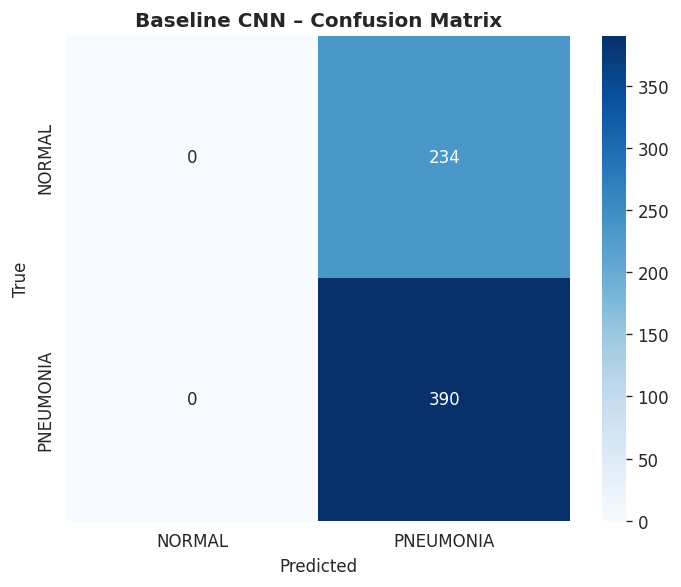

In [ ]:
# Evaluation helper
def evaluate_model(model, generator, name='Model'):
    generator.reset()
    y_prob = model.predict(generator, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = generator.classes

    print(f"\n{'='*55}")
    print(f"  {name}  –  Test Set Results")
    print('='*55)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} – Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_cm.png', bbox_inches='tight')
    plt.show()

    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    return report, y_pred, y_prob, y_true

base_report, base_pred, base_prob, base_true = evaluate_model(
    baseline_model, test_gen, 'Baseline CNN'
)


## 5. Hyperparameter Optimization
Using **Keras Tuner (Bayesian Optimization)** to tune:
- Dropout rate
- Learning rate


In [ ]:
def build_tunable_model(hp):

    dropout = hp.Choice('dropout', [0.05, 0.1, 0.2, 0.3])

    lr = hp.Float('learning_rate', min_value=1e-5, max_value=1e-1, sampling='log')
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop'])

    model = models.Sequential([
        layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu',
                      input_shape=(150, 150, 1), name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu', name='conv2'),
        layers.Dropout(dropout * 0.5),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu', name='conv3'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(128, (3,3), strides=1, padding='same', activation='relu', name='conv4'),
        layers.Dropout(dropout * 0.5),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(256, (3,3), strides=1, padding='same', activation='relu', name='conv5'),
        layers.Dropout(dropout * 0.5),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])


    if optimizer_choice == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
tuner = kt.BayesianOptimization(
    build_tunable_model,
    objective='val_accuracy',
    max_trials=30,
    directory='kt_results',
    project_name='pneumonia',
    overwrite=True
)

tuner.search(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[
        ReduceLROnPlateau(monitor='val_accuracy', patience=2,
                          factor=0.3, min_lr=0.000001)
    ],
    verbose=1
)


best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest hyperparameters:")
for k, v in best_hps.values.items():
    print(f"  {k}: {v}")

with open('best_hps.json', 'w') as f:
    json.dump(best_hps.values, f, indent=2)
print("\nSaved to best_hps.json")


# Trial 30 Complete [00h 12m 44s]
# val_accuracy: 0.9375

# Best val_accuracy So Far: 0.9375
# Total elapsed time: 06h 21m 58s

# Best hyperparameters:
#   dropout: 0.2
#   learning_rate: 0.00034655516315097815
#   optimizer: rmsprop

# Saved to best_hps.json


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
0.2               |0.2               |dropout
4.2637e-05        |4.2637e-05        |learning_rate
rmsprop           |rmsprop           |optimizer

Epoch 1/20


KeyboardInterrupt: 

In [ ]:
hpo_model = tuner.hypermodel.build(best_hps)

history_hpo = hpo_model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
        ModelCheckpoint('best_hpo.keras', monitor='val_accuracy', save_best_only=True)
    ],
    class_weight=class_weight,
    verbose=1
)


plot_history(history_hpo, 'HPO CNN')
hpo_report, hpo_pred, hpo_prob, hpo_true = evaluate_model(hpo_model, test_gen, 'HPO CNN')

# =======================================================
#   HPO CNN  –  Test Set Results
# =======================================================
#               precision    recall  f1-score   support

#       NORMAL     0.89      0.87     0.88     234
#    PNEUMONIA       0.92      0.93     0.93     390

#     accuracy                      0.91     624
#    macro avg       0.91      0.90     0.90     624
# weighted avg         0.91      0.91     0.91     624

NameError: name 'best_hps' is not defined

In [ ]:
# 直接用最佳超参构建模型
def build_best_hpo_model(input_shape=(150, 150, 1)):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu',
                      input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu', name='conv2'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(64, (3,3), strides=1, padding='same', activation='relu', name='conv3'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(128, (3,3), strides=1, padding='same', activation='relu', name='conv4'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Conv2D(256, (3,3), strides=1, padding='same', activation='relu', name='conv5'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2), strides=2, padding='same'),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=3.47e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

hpo_model = build_best_hpo_model()
hpo_model.summary()

history_hpo = hpo_model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
        ModelCheckpoint('best_hpo.keras', monitor='val_accuracy', save_best_only=True)
    ],
    class_weight=class_weight,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 239ms/step - accuracy: 0.8393 - loss: 0.5651 - val_accuracy: 0.5000 - val_loss: 15.3652 - learning_rate: 3.4700e-04
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 234ms/step - accuracy: 0.8832 - loss: 0.2981 - val_accuracy: 0.5000 - val_loss: 34.6860 - learning_rate: 3.4700e-04
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 233ms/step - accuracy: 0.9076 - loss: 0.2382 - val_accuracy: 0.5000 - val_loss: 57.3821 - learning_rate: 3.4700e-04
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 234ms/step - accuracy: 0.9256 - loss: 0.2233 - val_accuracy: 0.5000 - val_loss: 36.3338 - learning_rate: 3.4700e-04
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 234ms/step - accuracy: 0.9400 - loss: 0.1813 - val_accuracy: 0.6875 - val_loss: 1.1014 - learning_rate: 1.7350e-04
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 234ms/step - accuracy: 0.9427 - loss: 0.1696 - val_accuracy: 0.6875 - val_loss: 0.4152 - learning_rate: 1.7350e-04
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 38

In [ ]:
# Analyze on training set
train_eval_gen = eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False,
    seed=SEED
)

hpo_report_train, hpo_pred_train, hpo_prob_train, hpo_true_train = evaluate_model(
    hpo_model, train_eval_gen, 'HPO CNN (Train)'
)

NameError: name 'hpo_model' is not defined

## 6. Alternative Model – Transfer Learning (MobileNetV2)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/assignment2_models'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE_TRANSFER = (224, 224)
BATCH_SIZE = 32
SEED = 42


transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

transfer_eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

def make_transfer_generator(datagen, directory, shuffle=True):
    return datagen.flow_from_directory(
        directory,
        target_size=IMG_SIZE_TRANSFER,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        color_mode='rgb',
        shuffle=shuffle,
        seed=SEED
    )

transfer_train_gen = make_transfer_generator(transfer_train_datagen, TRAIN_DIR, shuffle=True)
transfer_val_gen   = make_transfer_generator(transfer_eval_datagen,  VAL_DIR,   shuffle=False)
transfer_test_gen  = make_transfer_generator(transfer_eval_datagen,  TEST_DIR,  shuffle=False)

print(f"Transfer train samples: {transfer_train_gen.samples}")
print(f"Transfer val samples  : {transfer_val_gen.samples}")
print(f"Transfer test samples : {transfer_test_gen.samples}")
print(f"Transfer class map    : {transfer_train_gen.class_indices}")


def build_transfer_model(input_shape=(224, 224, 3), base_trainable=False):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = base_trainable

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='Transfer_MobileNetV2')
    return model, base_model

tf.keras.backend.clear_session()

transfer_model, transfer_base = build_transfer_model(
    input_shape=(IMG_SIZE_TRANSFER[0], IMG_SIZE_TRANSFER[1], 3),
    base_trainable=False
)


transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        os.path.join(SAVE_DIR, 'best_transfer_stage1.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_transfer_stage1 = transfer_model.fit(
    transfer_train_gen,
    epochs=12,
    validation_data=transfer_val_gen,
    callbacks=callbacks_stage1,
    class_weight=class_weight,
    verbose=1
)

transfer_base.trainable = True
for layer in transfer_base.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        os.path.join(SAVE_DIR, 'best_transfer_finetuned.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_transfer_stage2 = transfer_model.fit(
    transfer_train_gen,
    epochs=12,
    validation_data=transfer_val_gen,
    callbacks=callbacks_stage2,
    class_weight=class_weight,
    verbose=1
)


best_transfer_model = keras.models.load_model(
    os.path.join(SAVE_DIR, 'best_transfer_finetuned.keras')
)

In [ ]:
plot_history(history_transfer_stage1, 'Transfer MobileNetV2 - Stage 1')
plot_history(history_transfer_stage2, 'Transfer MobileNetV2 - Stage 2 Fine-Tuning')

transfer_report, transfer_pred, transfer_prob, transfer_true = evaluate_model(
    best_transfer_model,
    transfer_test_gen,
    'Transfer MobileNetV2 Fine-Tuned'
)

In [ ]:
# Analyze on training set

transfer_report_train, transfer_pred_train, transfer_prob_train, transfer_true_train = evaluate_model(
    best_transfer_model,
    transfer_train_gen,
    'MobileNetV2 (Train)'
)

## 7. Results Summary Table

In [ ]:
def extract_metrics(report, cls=None):
    if cls is None:
        cls = [k for k in report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']][-1]

    return {
        'Accuracy':  round(report['accuracy'], 4),
        f'Precision ({cls})': round(report[cls]['precision'], 4),
        f'Recall ({cls})':    round(report[cls]['recall'],    4),
        f'F1 ({cls})':        round(report[cls]['f1-score'],  4),
    }

results = pd.DataFrame({
    'Baseline CNN': extract_metrics(base_report),
    'HPO CNN': extract_metrics(hpo_report),
    'Transfer MobileNetV2': extract_metrics(transfer_report),
}).T

print("\n" + "-"*60)
print("MODEL COMPARISON – TEST SET")
print("-"*60)
print(results.to_string())
print("-"*60)

# Best model is the Baseline model with hyperparameters got from HPO

## 8. XAI – Grad-CAM
**Grad-CAM** (Gradient-weighted Class Activation Mapping) uses the gradients of the  
target class flowing into the last convolutional layer to produce a coarse localization  
map highlighting which regions are important for the model's decision.


## Best Model:  Baseline Model with best hyperparameters:

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model_path = '/content/gdrive/My Drive/assignment2_models/best_hpo.keras'
TEST_DIR   = '/content/data/chest_xray/test'
LAST_CONV_LAYER_NAME = "conv5"
IMG_SIZE   = (150, 150)
IMG_CHANNELS = 1

model = keras.models.load_model(model_path)
model.build((None, IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS))
dummy = np.zeros((1, IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS), dtype=np.float32)
_ = model.predict(dummy, verbose=0)

model.summary()

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)
cls_map = {v: k for k, v in test_gen.class_indices.items()}
print("class map:", cls_map)

inp = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS))
x = inp
conv_output = None
for layer in model.layers:
    x = layer(x)
    if layer.name == LAST_CONV_LAYER_NAME:
        conv_output = x

feature_extractor = keras.Model(inputs=inp, outputs=conv_output)

classifier_input = keras.Input(shape=conv_output.shape[1:])
x = classifier_input
passed = False
for layer in model.layers:
    if layer.name == LAST_CONV_LAYER_NAME:
        passed = True
        continue
    if passed:
        x = layer(x)
classifier_model = keras.Model(classifier_input, x)



def get_balanced_misclassified_samples(model, generator, n_fp=4, n_fn=4):
    false_positives = []
    false_negatives = []
    generator.reset()
    for images, labels in generator:
        probs = model(images, training=False).numpy().flatten()
        preds = (probs > 0.5).astype(int)
        for img, label, pred, prob in zip(images, labels, preds, probs):
            label = int(label)
            pred = int(pred)
            prob = float(prob)
            if label == 0 and pred == 1 and len(false_positives) < n_fp:
                false_positives.append((img, label, pred, prob))
            elif label == 1 and pred == 0 and len(false_negatives) < n_fn:
                false_negatives.append((img, label, pred, prob))
            if len(false_positives) >= n_fp and len(false_negatives) >= n_fn:
                return false_positives + false_negatives
    return false_positives + false_negatives

mis_samples = get_balanced_misclassified_samples(model, test_gen, n_fp=4, n_fn=4)
print(f"收集到 {len(mis_samples)} 个误分类样本")

fp_count = sum(1 for _, label, pred, _ in mis_samples if label == 0 and pred == 1)
fn_count = sum(1 for _, label, pred, _ in mis_samples if label == 1 and pred == 0)
print(f"False Positives: {fp_count}, False Negatives: {fn_count}")

def make_gradcam_heatmap(img_array, feature_extractor, classifier_model):
    with tf.GradientTape() as tape:
        conv_output = feature_extractor(img_array, training=False)
        tape.watch(conv_output)
        preds = classifier_model(conv_output, training=False)
        loss  = preds[:, 0]
    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(img_uint8, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_rgb = plt.cm.jet(heatmap_resized)[..., :3]
    if img_uint8.ndim == 2:
        img_rgb = np.stack([img_uint8] * 3, axis=-1)
    elif img_uint8.shape[-1] == 1:
        img_rgb = np.concatenate([img_uint8] * 3, axis=-1)
    else:
        img_rgb = img_uint8
    img_rgb = img_rgb / 255.0
    overlay = (1 - alpha) * img_rgb + alpha * heatmap_rgb
    return np.clip(overlay, 0, 1)

def visualize_misclassified_gradcam(samples, feature_extractor, classifier_model, cls_map):
    n = len(samples)

    fig, axes = plt.subplots(n, 3, figsize=(14, 4.5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    col_titles = ['Original Image', 'Grad-CAM Heatmap', 'Overlay']

    for i, (img, label, pred, prob) in enumerate(samples):
        img_array = np.expand_dims(img, 0).astype(np.float32)
        img_uint8 = (img * 255).astype(np.uint8)

        heatmap = make_gradcam_heatmap(img_array, feature_extractor, classifier_model)
        overlay = overlay_heatmap(img_uint8, heatmap)

        disp = img_uint8.squeeze() if img_uint8.shape[-1] == 1 else img_uint8
        axes[i, 0].imshow(disp, cmap='gray' if disp.ndim == 2 else None)
        axes[i, 0].set_title(f"True: {cls_map[label]}", fontsize=11,
                             color='green' if label == 0 else 'red', fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title("Grad-CAM Heatmap", fontsize=11)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f"Pred: {cls_map[pred]} (conf: {prob:.3f})",
                             fontsize=11, color='red', fontweight='bold')
        axes[i, 2].axis('off')

        if i == 0:
            for j, ct in enumerate(col_titles):
                axes[i, j].set_title(f"{ct}\n{axes[i, j].get_title()}", fontsize=11)

    plt.suptitle(
        f"Grad-CAM on {n} Misclassified Test Samples (4 FP + 4 FN, HPO CNN)",
        fontsize=15, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig("gradcam_misclassified_hpo.png", dpi=150, bbox_inches='tight')
    print("saved: gradcam_misclassified_hpo.png")
    plt.show()

visualize_misclassified_gradcam(mis_samples, feature_extractor, classifier_model, cls_map)
print(" Grad-CAM finished")

# Integrated Gradients

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model_path = '/content/gdrive/My Drive/assignment2_models/best_hpo.keras'
TEST_DIR   = '/content/data/chest_xray/test'
IMG_SIZE   = (150, 150)
IMG_CHANNELS = 1
IG_STEPS   = 50

model = keras.models.load_model(model_path)
model.build((None, IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS))
dummy = np.zeros((1, IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS), dtype=np.float32)
_ = model.predict(dummy, verbose=0)


ig_inp = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS))
ig_x = ig_inp
for layer in model.layers:
    ig_x = layer(ig_x)
ig_model = keras.Model(inputs=ig_inp, outputs=ig_x)


test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)
cls_map = {v: k for k, v in test_gen.class_indices.items()}
print("class map:", cls_map)

def get_balanced_misclassified_samples(model, generator, n_fp=4, n_fn=4):
    false_positives = []
    false_negatives = []
    generator.reset()
    for images, labels in generator:
        probs = model(images, training=False).numpy().flatten()
        preds = (probs > 0.5).astype(int)
        for img, label, pred, prob in zip(images, labels, preds, probs):
            label = int(label)
            pred = int(pred)
            prob = float(prob)
            if label == 0 and pred == 1 and len(false_positives) < n_fp:
                false_positives.append((img, label, pred, prob))
            elif label == 1 and pred == 0 and len(false_negatives) < n_fn:
                false_negatives.append((img, label, pred, prob))
            if len(false_positives) >= n_fp and len(false_negatives) >= n_fn:
                return false_positives + false_negatives
    return false_positives + false_negatives

mis_samples = get_balanced_misclassified_samples(model, test_gen, n_fp=4, n_fn=4)


fp_count = sum(1 for _, label, pred, _ in mis_samples if label == 0 and pred == 1)
fn_count = sum(1 for _, label, pred, _ in mis_samples if label == 1 and pred == 0)
print(f"False Positives: {fp_count}, False Negatives: {fn_count}")

def integrated_gradients(ig_model, img_array, baseline=None, steps=IG_STEPS):
    if baseline is None:
        baseline = tf.zeros_like(img_array)
    img_array = tf.cast(img_array, tf.float32)
    baseline  = tf.cast(baseline,  tf.float32)

    alphas      = tf.linspace(0.0, 1.0, steps + 1)
    interp_imgs = baseline + alphas[:, None, None, None] * (img_array - baseline)

    with tf.GradientTape() as tape:
        tape.watch(interp_imgs)
        preds = ig_model(interp_imgs)
    grads = tape.gradient(preds, interp_imgs)

    avg_grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(avg_grads, axis=0)
    ig = avg_grads * (img_array[0] - baseline[0])
    return ig.numpy()

def ig_to_heatmap(ig_attrs):
    mag = np.abs(ig_attrs).sum(axis=-1)
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
    return mag

def overlay_heatmap(img_uint8, heatmap, alpha=0.45):
    hmap = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    hmap_rgb = cm.hot(hmap)[..., :3]
    if img_uint8.ndim == 2:
        img_rgb = np.stack([img_uint8] * 3, axis=-1)
    elif img_uint8.shape[-1] == 1:
        img_rgb = np.concatenate([img_uint8] * 3, axis=-1)
    else:
        img_rgb = img_uint8
    img_rgb = img_rgb / 255.0
    return np.clip((1 - alpha) * img_rgb + alpha * hmap_rgb, 0, 1)

def visualize_ig(samples, ig_model, cls_map):
    n = len(samples)

    fig, axes = plt.subplots(n, 3, figsize=(14, 4.5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    col_titles = ['Original Image', 'IG Attribution Map', 'IG Overlay']

    for i, (img, label, pred, prob) in enumerate(samples):
        img_array = np.expand_dims(img, 0).astype(np.float32)
        img_uint8 = (img * 255).astype(np.uint8)

        ig_attrs = integrated_gradients(ig_model, img_array)
        ig_map   = ig_to_heatmap(ig_attrs)
        ig_over  = overlay_heatmap(img_uint8, ig_map)

        disp = img_uint8.squeeze()
        axes[i, 0].imshow(disp, cmap='gray')
        axes[i, 0].set_title(f"True: {cls_map[label]}", fontsize=11,
                             color='green' if label == 0 else 'red', fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(ig_map, cmap='hot')
        axes[i, 1].set_title("IG Attribution", fontsize=11)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(ig_over)
        axes[i, 2].set_title(f"Pred: {cls_map[pred]} ({prob:.3f})",
                             fontsize=11, color='red', fontweight='bold')
        axes[i, 2].axis('off')

        if i == 0:
            for j, ct in enumerate(col_titles):
                axes[i, j].set_title(f"{ct}\n{axes[i, j].get_title()}", fontsize=11)

    plt.suptitle(
        f"Integrated Gradients on {n} Misclassified Samples (4 FP + 4 FN, HPO CNN)",
        fontsize=15, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig("ig_misclassified_hpo.png", dpi=150, bbox_inches='tight')
    print("saved: ig_misclassified_hpo.png")
    plt.show()

visualize_ig(mis_samples, ig_model, cls_map)
print("Integrated Gradients finished")